# Otimização Optuna

In [28]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.Data.Processor import DataStreamProcessor
from src.Classification.Optimizer import ClassificationOptunaOptimizer

# Instancia o processador
processor = DataStreamProcessor(logging=False)

# Carrega o dataset
# df = pd.read_csv('data/15k/Consistência/Consistência_25.csv')
df = pd.read_csv('data/15k/Consistência/Consistência_2000.csv')

# Criação do Stream
stream, targets, features = processor.create_stream(
    df=df,
    target_label_col='Label',
    binary_label=False,
    normalize_method="MinMaxScaler",
    threshold_var=0.005,
    threshold_corr=None,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
    imputation_method='mediana'
)

# Instancia o Otimizador
otimizador = ClassificationOptunaOptimizer(
    stream=stream,
    n_trials=15,             
    target_class=None
)

# Executa a otimização
# best_params_hat = otimizador.optimize('HAT')
best_params_arf = otimizador.optimize('ARF')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

[ARF] Iniciando otimização focada no F1-Score (Macro) com 15 trials...
Trial 1/15 | F1: 99.60 | Prec: 99.64 | Rec: 99.56 | Params: {'ensemble_size': 60, 'max_features': 0.8, 'lambda_param': 1.0, 'disable_weighted_vote': True, 'disable_drift_detection': False, 'disable_background_learner': False}
Trial 2/15 | F1: 99.48 | Prec: 99.49 | Rec: 99.47 | Params: {'ensemble_size': 150, 'max_features': 0.4, 'lambda_param': 10.0, 'disable_weighted_vote': True, 'disable_drift_detection': True, 'disable_background_learner': True}
Trial 3/15 | F1: 99.49 | Prec: 99.46 | Rec: 99.52 | Params: {'ensemble_size': 50, 'max_features': 0.4, 'lambda_param': 10.0, 'disable_weighted_vote': False, 'disable_drift_detection': True, 'disable_background_learner': False}
Trial 4/15 | F1: 99.49 | Prec: 99.54 | Rec: 99.44 | Params: {'ensemble_size': 20, 'max_features': 0.30000000000000004, 'lambda_param': 4.0, 'disable_weighted_vot

# Execução Pipeline

## Consistência

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

                             RELATÓRIO ACUMULATIVO                              
Modelo                    | Prec (%)   | Rec (%)    | F1 (%)    
--------------------------------------------------------------------------------
LeveragingBagging         |    99.70   |    99.73   |    99.72
HoeffdingAdaptiveTree     |    99.53   |    99.79   |    99.66



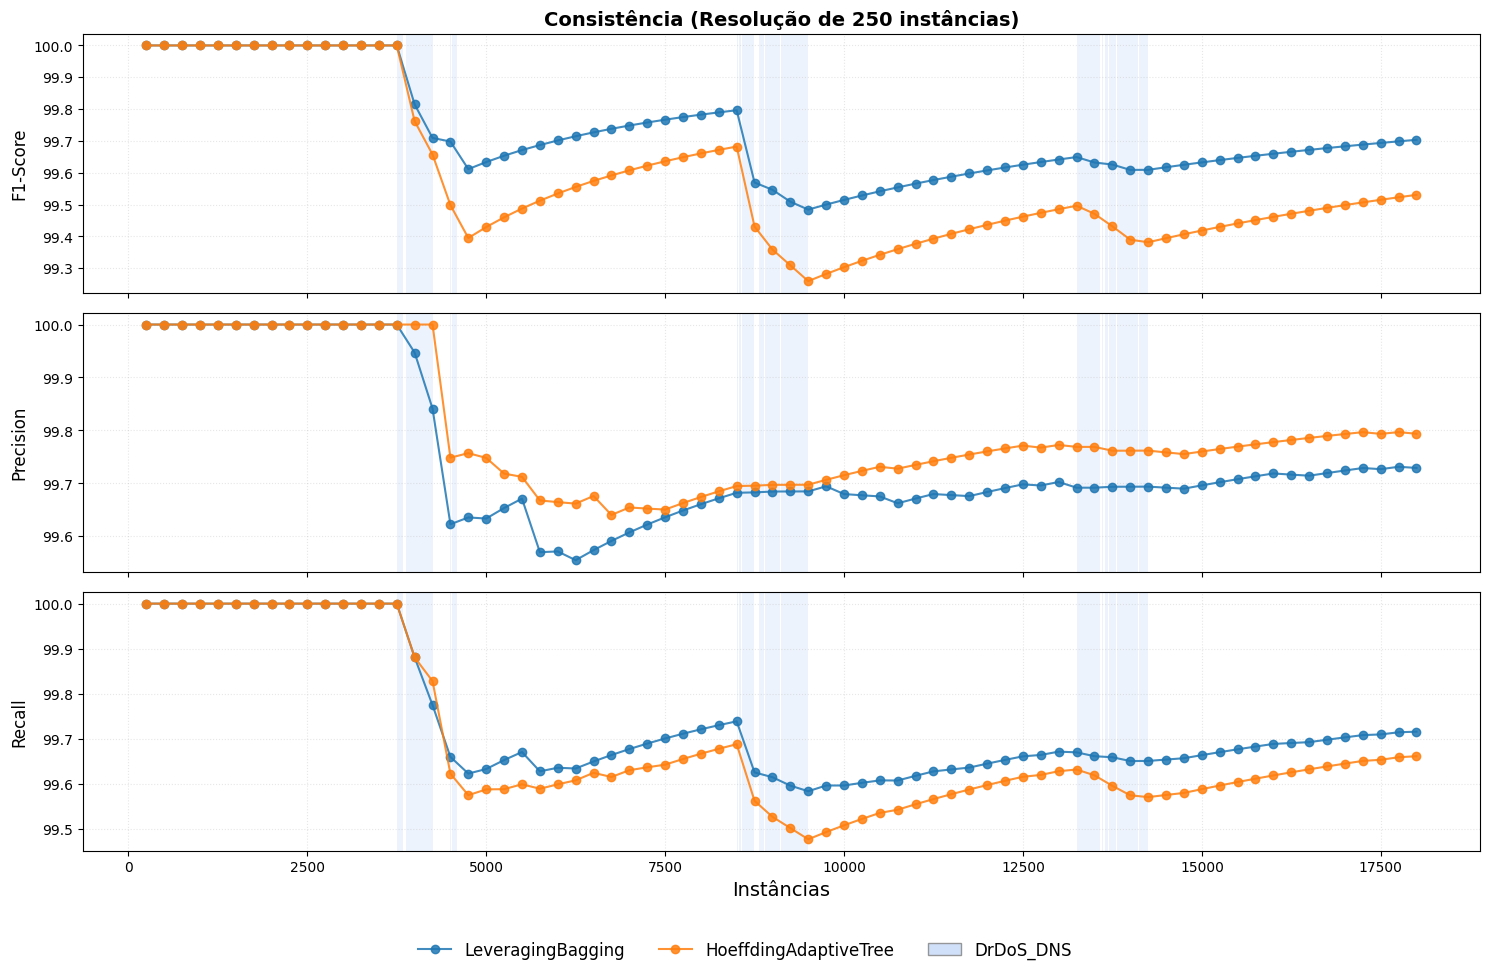

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.Data.Processor import DataStreamProcessor
from src.Classification.Pipeline import ClassificationExperimentRunner
from src.Classification.Models import get_classification_models

# Instancia o processador 
processor = DataStreamProcessor(logging=False)

# Carrega o dataset
# df = pd.read_csv('data/15k/Consistência/Consistência_25.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_250.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_500.csv')
df = pd.read_csv('data/15k/Consistência/Consistência_1000.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_2000.csv')

# Criação do Stream
stream, targets, features = processor.create_stream(
    df=df,
    target_label_col='Label',
    binary_label=False,
    normalize_method="StandardScaler",
    threshold_var=0.005,
    threshold_corr=None,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
    imputation_method='mediana'
)

# Configurar os algoritmos
algoritmos = get_classification_models(
    stream.get_schema(),
    selected_models=['HAT', 'LB']
)

# Instancia o objeto do experimento
runner = ClassificationExperimentRunner(target_names=targets)

# Executa a avaliação 
runner.run_classification_evaluation(
    stream=stream,
    algorithms=algoritmos,
    window_size=250,
    warmup_instances=250,
    title="Consistência",
    target_class=0
)

## Generalização

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

                             RELATÓRIO ACUMULATIVO                              
Modelo                    | Prec (%)   | Rec (%)    | F1 (%)    
--------------------------------------------------------------------------------
LeveragingBagging         |    99.58   |    99.79   |    99.68
HoeffdingAdaptiveTree     |    99.52   |    99.81   |    99.67



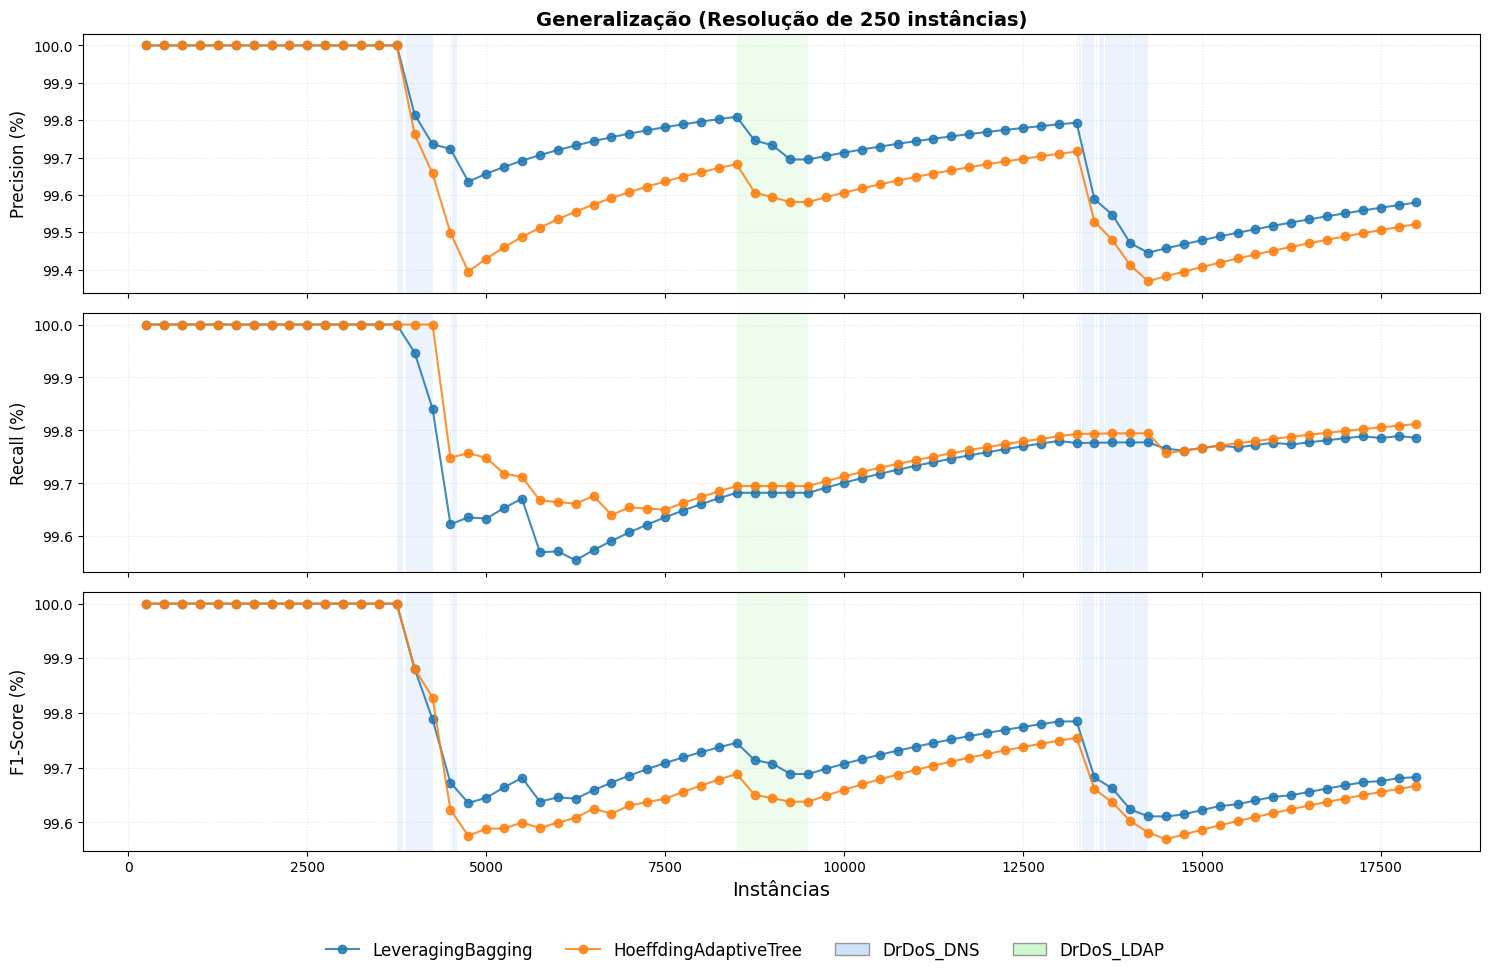

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.Data.Processor import DataStreamProcessor
from src.Classification.Pipeline import ClassificationExperimentRunner
from src.Classification.Models import get_classification_models

# Instancia o processador 
processor = DataStreamProcessor(logging=False)

# Carrega o dataset
# df = pd.read_csv('data/15k/Generalização/Generalização_25.csv')
# df = pd.read_csv('data/15k/Generalização/Generalização_250.csv')
# df = pd.read_csv('data/15k/Generalização/Generalização_500.csv')
df = pd.read_csv('data/15k/Generalização/Generalização_1000.csv')
# df = pd.read_csv('data/15k/Generalização/Generalização_2000.csv')

# Criação do Stream
stream, targets, features = processor.create_stream(
    df=df,
    target_label_col='Label',
    binary_label=False,
    normalize_method="StandardScaler",
    threshold_var=0.005,
    threshold_corr=None,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
    imputation_method='mediana'
)

# Configurar os algoritmos
algoritmos = get_classification_models(
    stream.get_schema(),
    selected_models=['HAT', 'LB']
)

# Instancia o objeto do experimento
runner = ClassificationExperimentRunner(target_names=targets)

# Executa a avaliação 
runner.run_classification_evaluation(
    stream=stream,
    algorithms=algoritmos,
    window_size=250,
    warmup_instances=250,
    title="Generalização",
    target_class=0
)

## Adaptação

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

                             RELATÓRIO ACUMULATIVO                              
Modelo                    | Prec (%)   | Rec (%)    | F1 (%)    
--------------------------------------------------------------------------------
LeveragingBagging         |    99.68   |    99.77   |    99.72
HoeffdingAdaptiveTree     |    99.54   |    99.81   |    99.67



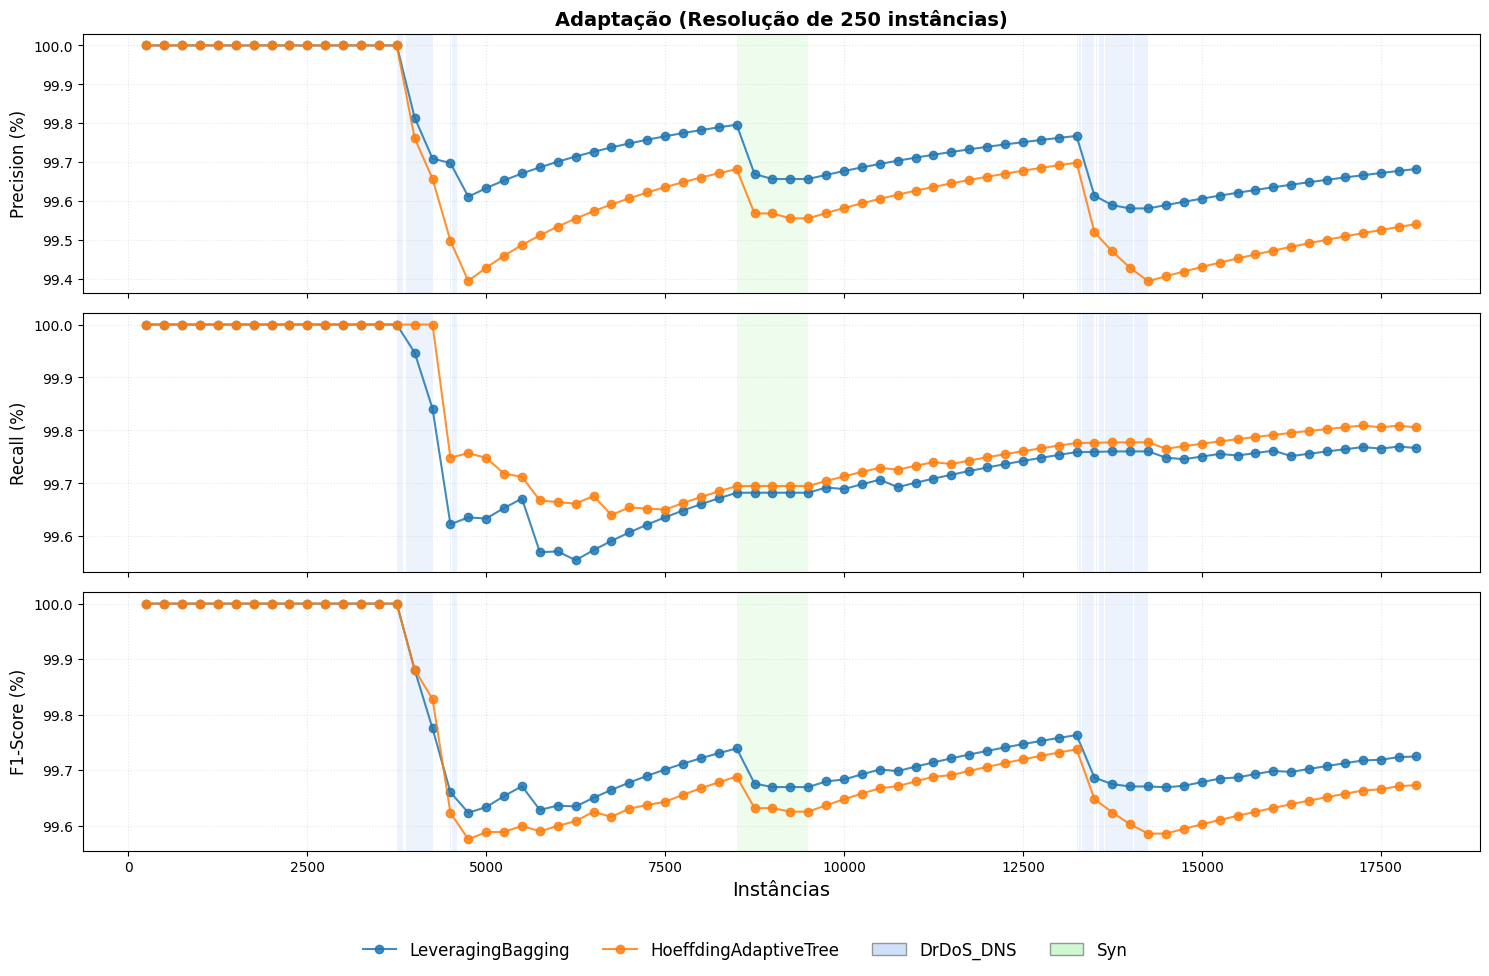

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.Data.Processor import DataStreamProcessor
from src.Classification.Pipeline import ClassificationExperimentRunner
from src.Classification.Models import get_classification_models

# Instancia o processador 
processor = DataStreamProcessor(logging=False)

# Carrega o dataset
# df = pd.read_csv('data/15k/Adaptação/Adaptação_25.csv')
# df = pd.read_csv('data/15k/Adaptação/Adaptação_250.csv')
# df = pd.read_csv('data/15k/Adaptação/Adaptação_500.csv')
df = pd.read_csv('data/15k/Adaptação/Adaptação_1000.csv')
# df = pd.read_csv('data/15k/Adaptação/Adaptação_2000.csv')

# Criação do Stream
stream, targets, features = processor.create_stream(
    df=df,
    target_label_col='Label',
    binary_label=False,
    normalize_method="StandardScaler",
    threshold_var=0.005,
    threshold_corr=None,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
    imputation_method='mediana'
)

# Configurar os algoritmos
algoritmos = get_classification_models(
    stream.get_schema(),
    selected_models=['HAT', 'LB']
)

# Instancia o objeto do experimento
runner = ClassificationExperimentRunner(target_names=targets)

# Executa a avaliação 
runner.run_classification_evaluation(
    stream=stream,
    algorithms=algoritmos,
    window_size=250,
    warmup_instances=250,
    title="Adaptação",
    target_class=0
)

## Recorrência

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

                             RELATÓRIO ACUMULATIVO                              
Modelo                    | Prec (%)   | Rec (%)    | F1 (%)    
--------------------------------------------------------------------------------
LeveragingBagging         |    99.67   |    99.82   |    99.74
HoeffdingAdaptiveTree     |    99.08   |    99.62   |    99.35



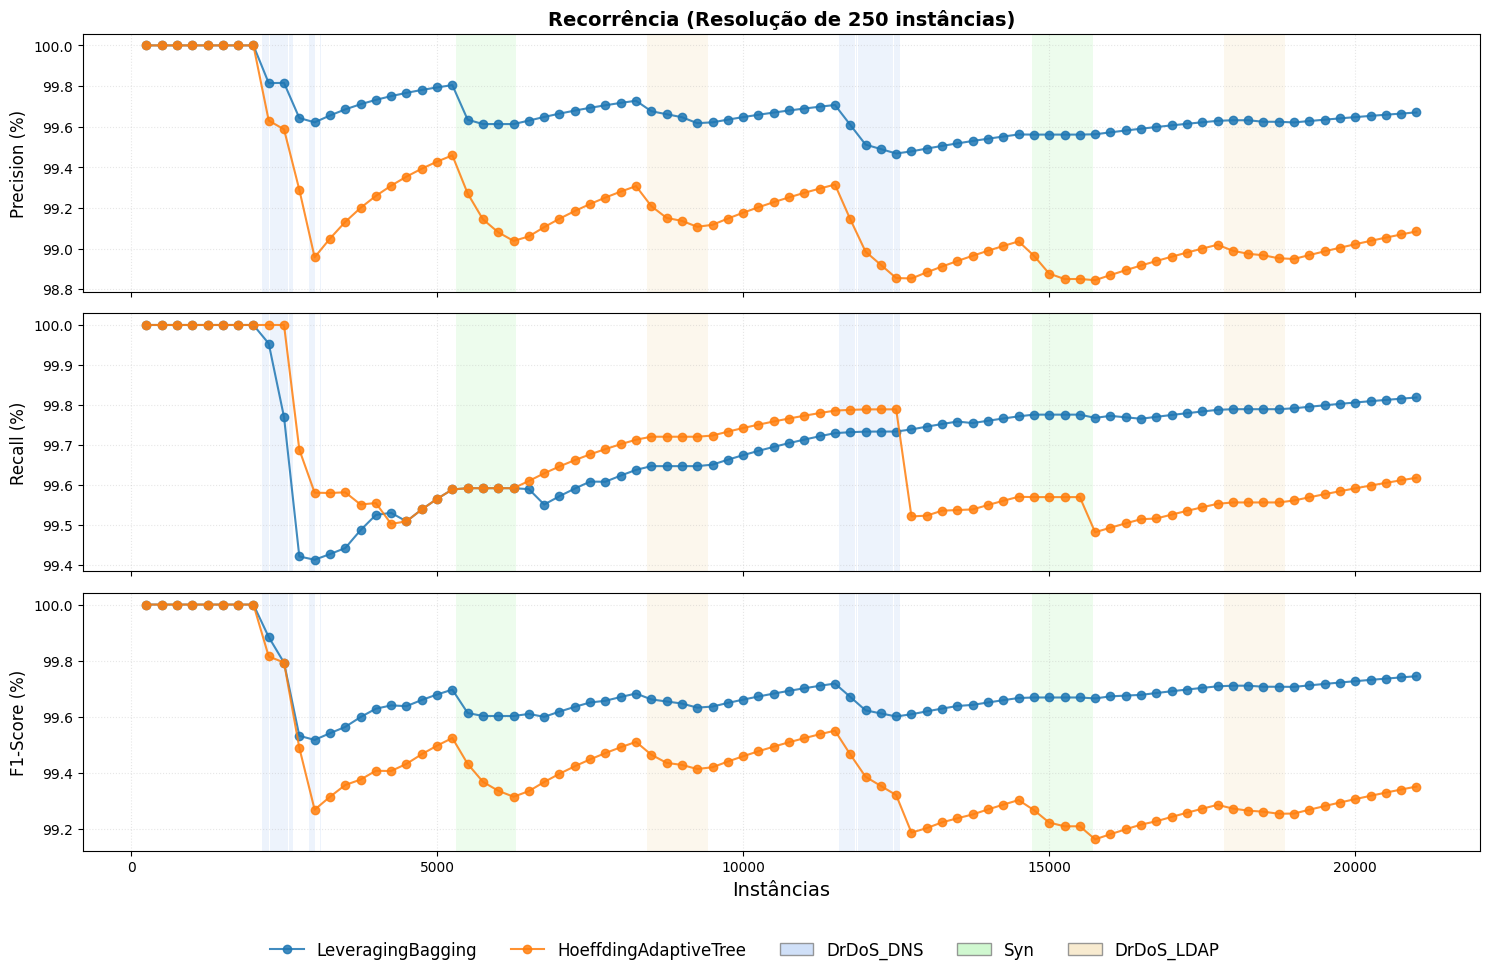

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.Data.Processor import DataStreamProcessor
from src.Classification.Pipeline import ClassificationExperimentRunner
from src.Classification.Models import get_classification_models

# Instancia o processador 
processor = DataStreamProcessor(logging=False)

# Carrega o dataset
# df = pd.read_csv('data/15k/Recorrência/Recorrência_25.csv')
# df = pd.read_csv('data/15k/Recorrência/Recorrência_250.csv')
# df = pd.read_csv('data/15k/Recorrência/Recorrência_500.csv')
df = pd.read_csv('data/15k/Recorrência/Recorrência_1000.csv')
# df = pd.read_csv('data/15k/Recorrência/Recorrência_2000.csv')

# Criação do Stream
stream, targets, features = processor.create_stream(
    df=df,
    target_label_col='Label',
    binary_label=False,
    normalize_method="StandardScaler",
    threshold_var=0.005,
    threshold_corr=None,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
    imputation_method='mediana'
)

# Configurar os algoritmos
algoritmos = get_classification_models(
    stream.get_schema(),
    selected_models=['HAT', 'LB']
)

# Instancia o objeto do experimento
runner = ClassificationExperimentRunner(target_names=targets)

# Executa a avaliação 
runner.run_classification_evaluation(
    stream=stream,
    algorithms=algoritmos,
    window_size=250,
    warmup_instances=250,
    title="Recorrência",
    target_class=0
)

## Warm-up

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

                             RELATÓRIO ACUMULATIVO                              
Modelo                    | Prec (%)   | Rec (%)    | F1 (%)    
--------------------------------------------------------------------------------
LeveragingBagging         |    99.91   |    99.99   |    99.95
HoeffdingAdaptiveTree     |    99.88   |   100.00   |    99.94



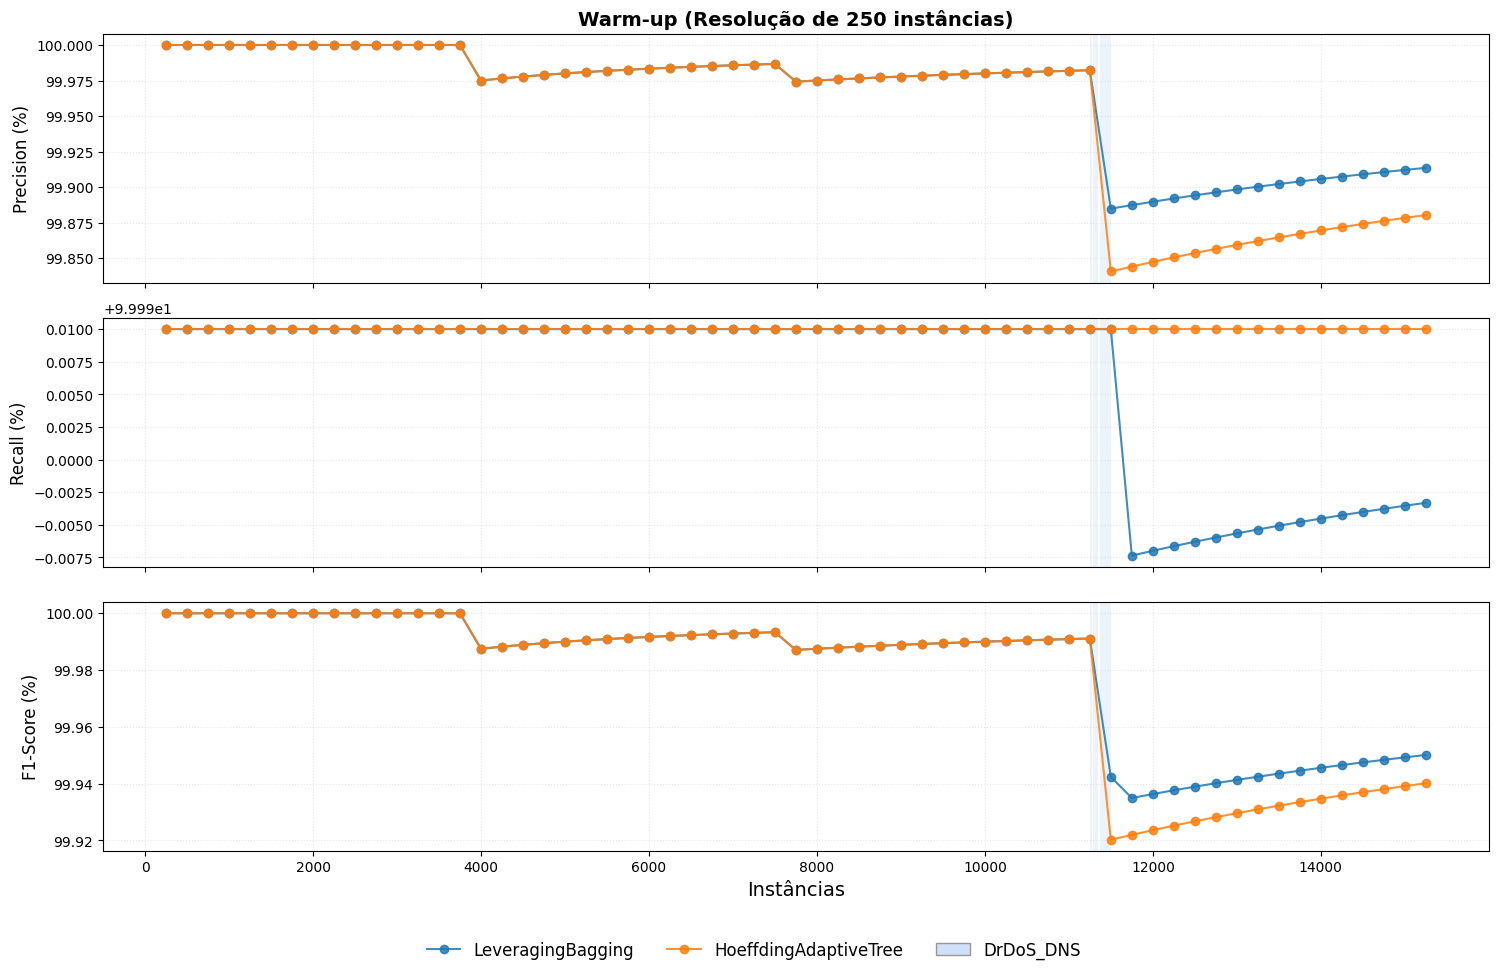

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from src.Data.Processor import DataStreamProcessor
from src.Classification.Pipeline import ClassificationExperimentRunner
from src.Classification.Models import get_classification_models

# Instancia o processador 
processor = DataStreamProcessor(logging=False)

# Carrega o dataset
# df = pd.read_csv('data/15k/Warm-up/Warm-up_1.csv')
# df = pd.read_csv('data/15k/Warm-up/Warm-up_2.csv')
df = pd.read_csv('data/15k/Warm-up/Warm-up_3.csv')

# Criação do Stream
stream, targets, features = processor.create_stream(
    df=df,
    target_label_col='Label',
    binary_label=False,
    normalize_method="StandardScaler",
    threshold_var=0.005,
    threshold_corr=None,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
    imputation_method='mediana'
)

# Configurar os algoritmos
algoritmos = get_classification_models(
    stream.get_schema(),
    selected_models=['HAT', 'LB']
)

# Instancia o objeto do experimento
runner = ClassificationExperimentRunner(target_names=targets)

# Executa a avaliação 
runner.run_classification_evaluation(
    stream=stream,
    algorithms=algoritmos,
    window_size=250,
    warmup_instances=250,
    title="Warm-up",
    target_class=0
)

# Prequential CapyMOA

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

                             RELATÓRIO ACUMULATIVO                              
Modelo                    | Prec (%)   | Rec (%)    | F1 (%)    
--------------------------------------------------------------------------------
AdaptiveRandomForest      |    99.85   |    99.70   |    99.77
HoeffdingTree             |    98.18   |    99.50   |    98.84



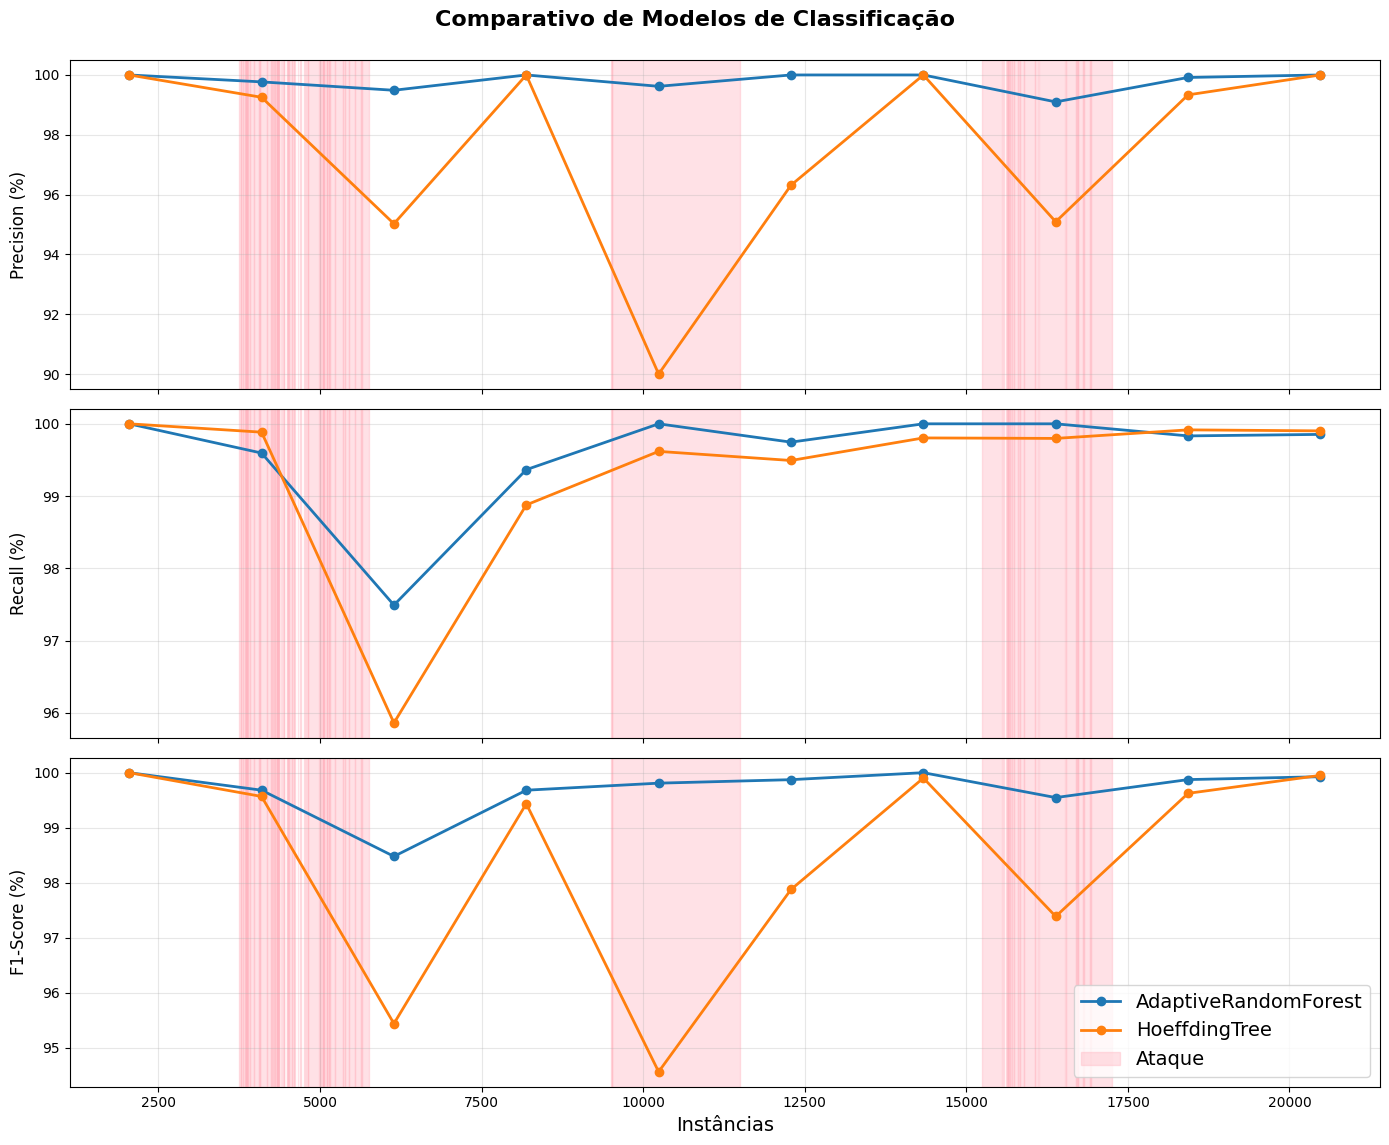

In [ ]:
%load_ext autoreload
%autoreload 2

from src.Classification.Models import get_classification_models
from src.Classification.Pipeline import ClassificationExperimentRunner
from src.Data.Processor import DataStreamProcessor
import pandas as pd

# Instancia o objeto
processor = DataStreamProcessor(logging=False)
runner = ClassificationExperimentRunner()

# df = pd.read_csv('data/15k/Adaptação/Adaptação_25.csv')
# df = pd.read_csv('data/15k/Adaptação/Adaptação_250.csv')
# df = pd.read_csv('data/15k/Adaptação/Adaptação_500.csv')
# df = pd.read_csv('data/15k/Adaptação/Adaptação_1000.csv')
df = pd.read_csv('data/15k/Adaptação/Adaptação_2000.csv')

stream, targets, features = processor.create_stream(
    df=df, 
    target_label_col='Label', 
    binary_label=True, 
    normalize_method="StandardScaler", 
    threshold_var=0.001,
    threshold_corr=0.85,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol'],
    imputation_method='mediana'
)

# Obter modelos
modelos = get_classification_models(stream.get_schema(), selected_models=['ARF', 'HT'])

# Treinar e avaliar os modelos
results, attacks = runner.run_experiments(stream, modelos, window_size=2048, logging=False)
runner.print_metrics(results)
runner.plot(results, attacks, title="Comparativo de Modelos de Classificação")

ARF accuracy = 99.68333333333334
HT accuracy = 99.16666666666667


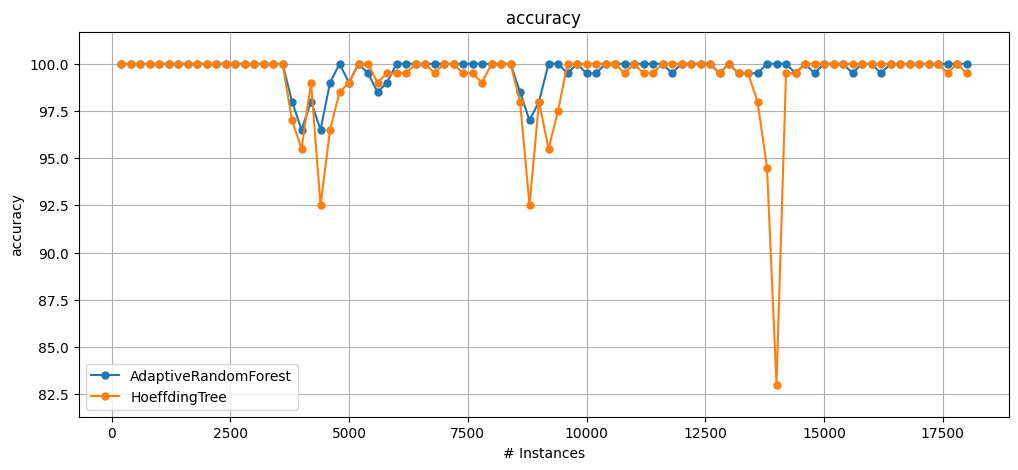

In [2]:
from capymoa.evaluation import prequential_evaluation_multiple_learners
from capymoa.evaluation.visualization import plot_windowed_results
from src.ClassificationModels import get_classification_models
from src.ClassificationPipeline import ClassificationExperimentRunner
from src.DataStreamProcessor import DataStreamProcessor
import pandas as pd

# Instancia o objeto
processor = DataStreamProcessor(logging=False)
runner = ClassificationExperimentRunner()

# df = pd.read_csv('data/15k/Consistência/Consistência_25.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_250.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_500.csv')
df = pd.read_csv('data/15k/Consistência/Consistência_1000.csv')
# df = pd.read_csv('data/15k/Consistência/Consistência_2000.csv')

stream, targets, features = processor.create_stream(
    df=df, 
    target_label_col='Label', 
    binary_label=True, 
    normalize_method="StandardScaler", 
    threshold_var=0.001,
    threshold_corr=0.85,
    top_n_features=None,
    return_stream=True,
    extra_ignore_cols=['Source IP', 'Source Port','Destination IP','Destination Port','Protocol'],
    imputation_method='mediana'
)

# Obter modelos
modelos = get_classification_models(stream.get_schema(), selected_models=['ARF', 'HT'])

# Executar avaliação prequential
results = prequential_evaluation_multiple_learners(stream, modelos, window_size=200, max_instances=len(df))

# Exibir resultados
if 'LeveragingBagging' in results:
    print(f"LB accuracy = {results['LeveragingBagging'].cumulative.accuracy()}")

if 'HoeffdingAdaptiveTree' in results:
    print(f"HAT accuracy = {results['HoeffdingAdaptiveTree'].cumulative.accuracy()}")

if 'AdaptiveRandomForest' in results:
    print(f"ARF accuracy = {results['AdaptiveRandomForest'].cumulative.accuracy()}")

if 'HoeffdingTree' in results:
    print(f"HT accuracy = {results['HoeffdingTree'].cumulative.accuracy()}")

plot_windowed_results(*results.values(), metric="accuracy", save_only=False)